In [ ]:
import pandas as pd

In [ ]:
df1 = pd.read_excel('/content/Mad_1.XLSX')
df2 = pd.read_excel('/content/Mad_2.XLSX')

In [ ]:
df1 = df1.dropna(axis=1, how='all')
df2 = df2.dropna(axis=1, how='all')

In [ ]:
df1.columns = df1.iloc[3]
df2.columns = df2.iloc[3]

In [ ]:
df1 = df1.iloc[4:].reset_index(drop=True)
df2 = df2.iloc[4:].reset_index(drop=True)

In [ ]:
df1 = df1.rename(columns={df1.columns[0]: "Item"})
df2 = df2.rename(columns={df2.columns[0]: "Item"})

In [ ]:
for col in df1.columns[1:]:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

for col in df2.columns[1:]:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

df1.head()

3,Item,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25
0,1,2.0,3.0,4.0,5.0,6.0,7.0,8.0
1,Population (in Lakhs),13270.0,13410.0,13554.0,13686.0,13829.0,13950.0,14080.0
2,GVA at Basic Prices,17175128.0,18381117.0,18210997.0,21635584.0,24646698.0,27412888.0,30022033.0
3,Net Taxes on Products,1724540.0,1722476.0,1643099.0,1961815.0,2243775.0,2710068.0,3046113.0
4,Gross Domestic Product,18899668.0,20103593.0,19854096.0,23597399.0,26890473.0,30122956.0,33068145.0


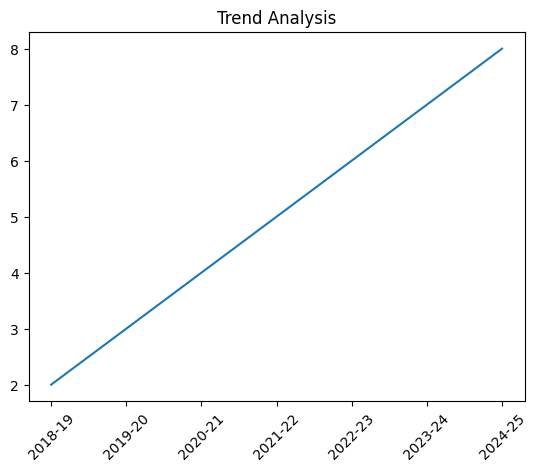

In [ ]:
import matplotlib.pyplot as plt
row = df1.iloc[0]

years = df1.columns[1:]
values = row[1:]

plt.plot(years, values)
plt.title("Trend Analysis")
plt.xticks(rotation=45)
plt.show()

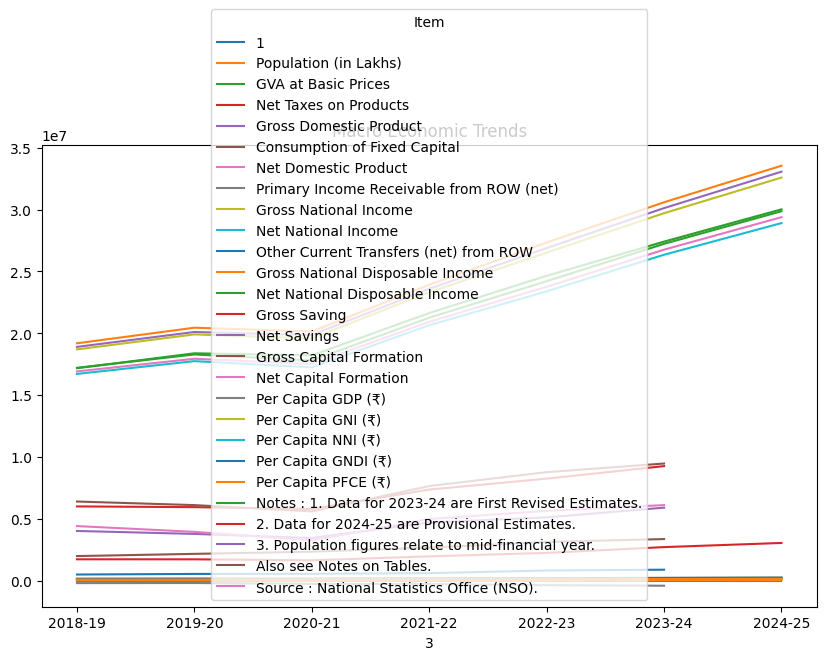

In [ ]:
df1.set_index('Item').T.plot(figsize=(10,6))
plt.title("Macro Economic Trends")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Example: Predict one indicator
row = df1.iloc[0]

X = np.array(range(len(df1.columns[1:]))).reshape(-1,1)
y = row[1:].values

model = LinearRegression()
model.fit(X, y)

# Predict next year
next_year = model.predict([[len(X)]])
print("Prediction:", next_year)

Prediction: [9.]


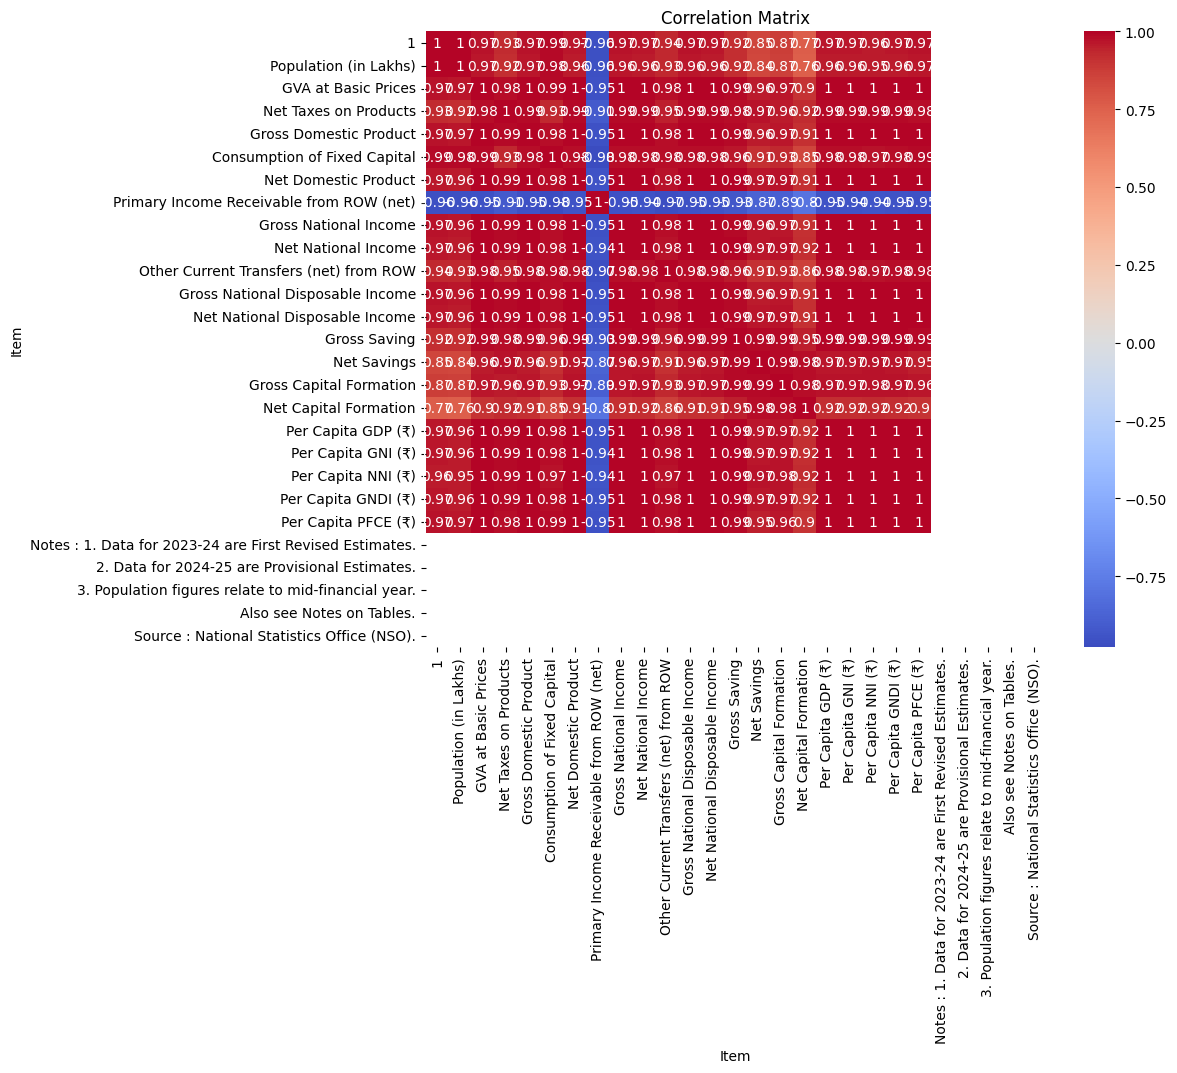

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Transpose so years become rows
df_corr = df1.set_index('Item').T

# Correlation
corr = df_corr.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X)

print("MAE:", mean_absolute_error(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
print("R2 Score:", r2_score(y, y_pred))

MAE: 0.0
MSE: 0.0
RMSE: 0.0
R2 Score: 1.0


In [18]:
import numpy as np

# Example: classify increase or decrease
y_class = np.where(np.diff(y, prepend=y[0]) > 0, 1, 0)

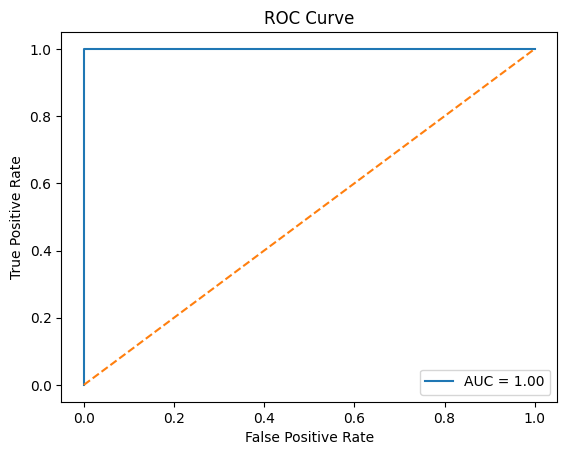

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

model_clf = LogisticRegression()
model_clf.fit(X, y_class)

y_prob = model_clf.predict_proba(X)[:,1]

fpr, tpr, thresholds = roc_curve(y_class, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X, y)

print("Feature Importance:", rf.feature_importances_)

Feature Importance: [1.]
